In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [65]:
DATA_DIR = Path("../../data/processed")

model_df = pd.read_csv(
    DATA_DIR / "model_data.csv"
)

In [66]:
df = model_df.copy()
df.head()

,set,set_release_date,obs_date,t,rarity,pull_rate,card,number,is_pokemon,is_chase,price_on_release,current_price,popularity_index,ebay_index,set_popularity_index
0,151,2023-09-22,2026-08-24 00:20:52.463258,0,Double Rare,0.010417,Venusaur ex,3,True,False,0.85,0.85,0.64557,0.839349,0.811
1,151,2023-09-22,2026-08-24 00:20:52.463258,1,Double Rare,0.010417,Venusaur ex,3,True,False,0.85,0.98,0.64557,0.839349,0.811
2,151,2023-09-22,2026-08-24 00:20:52.463258,2,Double Rare,0.010417,Venusaur ex,3,True,False,0.85,0.67,0.64557,0.839349,0.811
3,151,2023-09-22,2026-08-24 00:20:52.463258,3,Double Rare,0.010417,Venusaur ex,3,True,False,0.85,0.74,0.64557,0.839349,0.811
4,151,2023-09-22,2026-08-24 00:20:52.463258,4,Double Rare,0.010417,Venusaur ex,3,True,False,0.85,0.76,0.64557,0.839349,0.811


In [67]:
# Categorical Encodings (Index mapping for Hierarchical Pooling)
set_categories = df['set'].astype('category')
rarity_categories = df['rarity'].astype('category')

df['set_idx'] = set_categories.cat.codes

df["rarity_idx"] = rarity_categories.cat.codes

mappings = {
    'sets': set_categories.cat.categories,
    'rarities': rarity_categories.cat.categories,
}

mappings

{'sets': Index(['151', 'Ascended Heroes', 'Astral Radiance', 'Battle Styles',
        'Black Bolt', 'Brilliant Stars', 'Champion's Path', 'Chaos Rising',
        'Chilling Reign', 'Crown Zenith', 'Darkness Ablaze', 'Destined Rivals',
        'Evolving Skies', 'Fusion Strike', 'Journey Together', 'Lost Origin',
        'Mega Evolution', 'Obsidian Flames', 'Paldea Evolved', 'Paldean Fates',
        'Paradox Rift', 'Perfect Order', 'Phantasmal Flames',
        'Prismatic Evolutions', 'Rebel Clash', 'Scarlet & Violet',
        'Shining Fates', 'Shrouded Fable', 'Silver Tempest', 'Stellar Crown',
        'Surging Sparks', 'Sword & Shield', 'Temporal Forces',
        'Twilight Masquerade', 'Vivid Voltage', 'White Flare'],
       dtype='object'),
 'rarities': Index(['ACE SPEC Rare', 'Black White Rare', 'Double Rare', 'Holo Rare',
        'Holo Rare V', 'Holo Rare VMAX', 'Holo Rare VSTAR', 'Hyper Rare',
        'Illustration Rare', 'Mega Hyper Rare', 'Radiant Rare', 'Secret Rare',
        'Shi

In [68]:
# Ensure datetime formats
df['obs_date'] = pd.to_datetime(df['obs_date']).dt.normalize()
df['set_release_date'] = pd.to_datetime(df['set_release_date'])

In [69]:
days_since_release = (df['obs_date'] - df['set_release_date']).dt.days
df['true_age_months'] = np.maximum(0, days_since_release / 30.4375)
df['log_true_age'] = np.log1p(df['true_age_months'])
df['is_mature'] = (df['true_age_months'] >= 24).astype(float)

In [70]:
# Target Variable: Log Return r_t = ln(P_t / P_{t-1})
df['log_price'] = np.log(df['current_price'])
df['target_log_return'] = df.groupby('card')['log_price'].diff()

In [71]:
# Lagged Log Return (r_{t-1})
df['lag_log_return'] = df.groupby('card')['target_log_return'].shift(1)

In [72]:
# Non-linear Time Decay Feature: ln(t)
df['log_t'] = np.log(df['t'] + 1e-6)

In [73]:
# Relative Popularity: Card popularity relative to its set average
df['rel_popularity'] = df['popularity_index'] / (df['set_popularity_index'] + 1e-6)

In [74]:
# Set Momentum: Average lagged return of all cards in the same set at time t
df['set_momentum'] = df.groupby(['set_idx', 't'])['lag_log_return'].transform('mean')

In [75]:
clean_df = df.dropna(
    subset=['target_log_return', 'lag_log_return', 'set_momentum']
).reset_index(drop=True)
cols_to_scale = ['log_t', 'rel_popularity', 'lag_log_return', 'set_momentum']
clean_df[cols_to_scale] = (clean_df[cols_to_scale] - clean_df[cols_to_scale].mean()) / clean_df[cols_to_scale].std()
clean_df.head()

,set,set_release_date,obs_date,t,rarity,pull_rate,card,number,is_pokemon,is_chase,...,rarity_idx,true_age_months,log_true_age,is_mature,log_price,target_log_return,lag_log_return,log_t,rel_popularity,set_momentum
0,151,2023-09-22,2026-08-24,2,Double Rare,0.010417,Venusaur ex,3,True,False,...,2,35.055441,3.585058,1.0,-0.400478,-0.380275,0.241816,-0.175972,-0.069502,0.268539
1,151,2023-09-22,2026-08-24,3,Double Rare,0.010417,Venusaur ex,3,True,False,...,2,35.055441,3.585058,1.0,-0.301105,0.099372,-1.067324,-0.035748,-0.069502,-0.438805
2,151,2023-09-22,2026-08-24,4,Double Rare,0.010417,Venusaur ex,3,True,False,...,2,35.055441,3.585058,1.0,-0.274437,0.026668,0.134238,0.063742,-0.069502,-0.514829
3,151,2023-09-22,2026-08-24,5,Double Rare,0.010417,Venusaur ex,3,True,False,...,2,35.055441,3.585058,1.0,-0.314711,-0.040274,-0.047893,0.140913,-0.069502,-0.172025
4,151,2023-09-22,2026-08-24,6,Double Rare,0.010417,Venusaur ex,3,True,False,...,2,35.055441,3.585058,1.0,0.029559,0.344270,-0.215590,0.203966,-0.069502,0.017147


In [76]:
import pymc as pm

def build_and_fit_hbm(clean_df, mappings, draws=1000, tune=1000, target_accept=0.96):
    continuous_cols = ['log_true_age', 'rel_popularity', 'lag_log_return', 'set_momentum']
    scaled_df = clean_df.copy()
    
    scaler_means = scaled_df[continuous_cols].mean()
    scaler_stds = scaled_df[continuous_cols].std()
    scaled_df[continuous_cols] = (scaled_df[continuous_cols] - scaler_means) / scaler_stds

    set_idx = scaled_df['set_idx'].values
    rarity_idx = scaled_df['rarity_idx'].values
    
    log_true_age = scaled_df['log_true_age'].values
    is_mature = scaled_df['is_mature'].values
    rel_pop = scaled_df['rel_popularity'].values
    lag_ret = scaled_df['lag_log_return'].values
    set_mom = scaled_df['set_momentum'].values
    
    y_obs = scaled_df['target_log_return'].values

    coords = {
        "set": mappings['sets'],
        "rarity": mappings['rarities'],
        "obs": np.arange(len(scaled_df))
    }

    with pm.Model(coords=coords) as hbm_model:
        mu_0 = pm.Normal("mu_0", mu=0.0, sigma=0.1)
        
        sigma_set = pm.HalfNormal("sigma_set", sigma=0.1)
        sigma_rarity = pm.HalfNormal("sigma_rarity", sigma=0.1)

        a_set_raw = pm.Normal("a_set_raw", mu=0, sigma=1, dims="set")
        a_rarity_raw = pm.Normal("a_rarity_raw", mu=0, sigma=1, dims="rarity")

        a_set = pm.Deterministic("a_set", a_set_raw * sigma_set, dims="set")
        a_rarity = pm.Deterministic("a_rarity", a_rarity_raw * sigma_rarity, dims="rarity")


        b_age_new = pm.Normal("b_age_new", mu=-0.05, sigma=0.2)
        
        b_age_mature_delta = pm.Normal("b_age_mature_delta", mu=0.05, sigma=0.2)
        
        b_rel_pop = pm.Normal("b_rel_pop", mu=0.0, sigma=0.2)
        b_lag = pm.Normal("b_lag", mu=0.0, sigma=0.2)
        b_set_mom = pm.Normal("b_set_mom", mu=0.0, sigma=0.2)

        effective_age_slope = b_age_new + (b_age_mature_delta * is_mature)

        mu = (
            mu_0 
            + a_set[set_idx] 
            + a_rarity[rarity_idx] 
            + effective_age_slope * log_true_age
            + b_rel_pop * rel_pop 
            + b_lag * lag_ret 
            + b_set_mom * set_mom
        )

        sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.1)
        nu = pm.Gamma("nu", alpha=2, beta=0.1) 

        y_eval = pm.StudentT(
            "y_obs", 
            nu=nu, 
            mu=mu, 
            sigma=sigma_obs, 
            observed=y_obs, 
            dims="obs"
        )

        idata = pm.sample(
            draws=draws, 
            tune=tune, 
            chains=4, 
            target_accept=0.98,
            return_inferencedata=True
        )

    return hbm_model, idata, scaler_means, scaler_stds

In [78]:
model, idata, scaler_means, scaler_stds = build_and_fit_hbm(clean_df, mappings, draws=1000, tune=2000, target_accept=0.97)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_0, sigma_set, sigma_rarity, a_set_raw, a_rarity_raw, b_age_new, b_age_mature_delta, b_rel_pop, b_lag, b_set_mom, sigma_obs, nu]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 241 seconds.


In [80]:
import arviz as az

az.summary(idata, var_names=["mu_0", "b_age_new", "b_age_mature_delta", "b_rel_pop", "b_lag", "b_set_mom", "sigma_set", "sigma_rarity"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_0,0.0201,0.008,0.0072,0.033,758,989,1.01,0.00029,0.00022
b_age_new,0.0379,0.0054,0.029,0.047,945,1112,1.01,0.00018,0.00013
b_age_mature_delta,-0.0389,0.0126,-0.06,-0.019,719,889,1.00,0.00047,0.00034
b_rel_pop,0.00874,0.00098,0.0072,0.01,3584,2813,1.00,1.6e-05,1.2e-05
b_lag,-0.00671,0.00137,-0.009,-0.0045,2623,2433,1.00,2.7e-05,2e-05
b_set_mom,0.01484,0.00135,0.013,0.017,2611,2322,1.00,2.7e-05,1.9e-05
sigma_set,0.0252,0.0036,0.02,0.031,952,1311,1.00,0.00011,8.8e-05
sigma_rarity,0.0158,0.004,0.011,0.023,1014,1476,1.01,0.00012,0.00013


Sampling: [y_obs]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

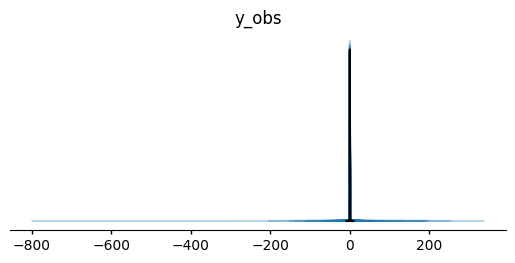

In [81]:
from arviz_plots import plot_ppc_dist
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="arviz")

with model:
    ppc = pm.sample_posterior_predictive(idata, extend_inferencedata=True)

plot_ppc_dist(idata, num_samples=100)

In [85]:
from sklearn.metrics import mean_absolute_error

def run_time_series_backtest(clean_df, mappings, test_t_values=[9, 10, 11, 12]):
    results = []
    
    continuous_cols = ['log_t', 'rel_popularity', 'lag_log_return', 'set_momentum']

    for test_t in test_t_values:
        print(f"\n--- Running Backtest for t={test_t} ---")
        
        train_df = clean_df[clean_df['t'] < test_t].copy()
        test_df = clean_df[clean_df['t'] == test_t].copy()
        
        if test_df.empty:
            print(f"No data for t={test_t}, skipping.")
            continue

        train_mean = train_df[continuous_cols].mean()
        train_std = train_df[continuous_cols].std()
        
        train_df[continuous_cols] = (train_df[continuous_cols] - train_mean) / train_std
        test_df[continuous_cols] = (test_df[continuous_cols] - train_mean) / train_std

        _, idata, _, _ = build_and_fit_hbm(train_df, mappings, draws=1000, tune=1500, target_accept=0.97)

        print(
            az.summary(idata, var_names=["mu_0", "b_age_new", "b_age_mature_delta", "b_rel_pop", "b_lag", "b_set_mom", "sigma_set", "sigma_rarity"])
        )
        
        posterior = idata.posterior
        mu_0_mean = posterior['mu_0'].mean().item()
        b_age_new_mean = posterior['b_age_new'].mean().item()
        b_age_mature_delta_mean = posterior['b_age_mature_delta'].mean().item()
        b_rel_pop_mean = posterior['b_rel_pop'].mean().item()
        b_lag_mean = posterior['b_lag'].mean().item()
        b_set_mom_mean = posterior['b_set_mom'].mean().item()

        a_set_means = posterior['a_set'].mean(dim=['chain', 'draw']).to_dataframe()['a_set']
        a_rarity_means = posterior['a_rarity'].mean(dim=['chain', 'draw']).to_dataframe()['a_rarity']

        test_a_set = test_df['set_idx'].map(a_set_means).fillna(0)
        test_a_rarity = test_df['rarity_idx'].map(a_rarity_means).fillna(0)
        
        y_pred = (
            mu_0_mean
            + test_a_set.values
            + test_a_rarity.values
            + b_age_new_mean * test_df['log_true_age'].values
            + b_age_mature_delta_mean * test_df['is_mature'].values
            + b_rel_pop_mean * test_df['rel_popularity'].values
            + b_lag_mean * test_df['lag_log_return'].values
            + b_set_mom_mean * test_df['set_momentum'].values
        )
        
        y_true = test_df['target_log_return'].values
        
        mae = mean_absolute_error(y_true, y_pred)
        
        sign_match = np.sign(y_true) == np.sign(y_pred)
        dir_acc = np.mean(sign_match) * 100
        
        print(f"Results for t={test_t}:")
        print(f"MAE: {mae:.4f}")
        print(f"Directional Accuracy: {dir_acc:.1f}%")
        
        results.append({
            't': test_t,
            'mae': mae,
            'directional_accuracy': dir_acc,
            'n_predictions': len(y_true)
        })

    return pd.DataFrame(results), idata

In [87]:
results, idata = run_time_series_backtest(clean_df, mappings, test_t_values=[8, 9, 10, 11, 12])

Initializing NUTS using jitter+adapt_diag...



--- Running Backtest for t=8 ---


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_0, sigma_set, sigma_rarity, a_set_raw, a_rarity_raw, b_age_new, b_age_mature_delta, b_rel_pop, b_lag, b_set_mom, sigma_obs, nu]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 91 seconds.


...

                        mean       sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
mu_0                  0.0317   0.0086    0.018    0.045      674      912  1.00   0.00033  0.00024
b_age_new             0.0444   0.0055    0.036    0.053      881     1141  1.00   0.00019  0.00014
b_age_mature_delta     -0.05   0.0128   -0.071   -0.031      639      782  1.01   0.00051  0.00038
b_rel_pop            0.00932   0.0011   0.0076    0.011     3022     2771  1.00     2e-05  1.4e-05
b_lag               -0.00412  0.00126  -0.0062  -0.0021     2653     2661  1.00   2.5e-05  1.8e-05
b_set_mom            0.01182  0.00131   0.0097    0.014     2629     2500  1.00   2.6e-05  1.8e-05
sigma_set             0.0233   0.0035    0.018    0.029      719     1133  1.01   0.00013  0.00011
sigma_rarity          0.0178   0.0045    0.012    0.026     1094     1600  1.00   0.00014  0.00017
Results for t=11:
MAE: 0.1818
Directional Accuracy: 45.8%

--- Running Backtest for t=12 ---


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_0, sigma_set, sigma_rarity, a_set_raw, a_rarity_raw, b_age_new, b_age_mature_delta, b_rel_pop, b_lag, b_set_mom, sigma_obs, nu]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 222 seconds.


                        mean       sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
mu_0                  0.0245   0.0083    0.011    0.038      753      999  1.00    0.0003  0.00023
b_age_new             0.0413   0.0055    0.033     0.05     1044     1386  1.00   0.00017  0.00013
b_age_mature_delta   -0.0422   0.0124   -0.062   -0.023      867     1173  1.01   0.00042  0.00032
b_rel_pop            0.00957  0.00101   0.0079    0.011     2439     2657  1.00     2e-05  1.4e-05
b_lag               -0.00524  0.00127  -0.0073  -0.0032     2936     2964  1.00   2.3e-05  1.7e-05
b_set_mom            0.01274  0.00128    0.011    0.015     2705     2655  1.00   2.5e-05  1.7e-05
sigma_set             0.0253   0.0036     0.02    0.031      710      996  1.01   0.00013  0.00011
sigma_rarity          0.0174   0.0042    0.012    0.025     1200     1792  1.00   0.00012  0.00011
Results for t=12:
MAE: 0.1776
Directional Accuracy: 37.3%
